In [1]:
import matplotlib.pyplot as plt
import dask.array as da
import icechunk
import numpy as np
import xarray as xr
import zarr

from metaarrays.metaarray import construct_metaarray
from metaarrays.transform import Centroid, FirstCoordinate
from metaarrays.mapper import Mapper, MapSpec, Level, Space, Spec

# MetaArrays

### Initialize Icechunk Repo

In [3]:
repo = icechunk.Repository.create(icechunk.in_memory_storage())
group = "mydata"
session = repo.writable_session("main")
store = session.store

### Write data

This dataset has 10 billion chunks. This is enough for it to be unfeasible to load even the MetaArray into memory.

In [4]:
n = 10000
nt = 10000
ds = xr.Dataset(
    {
        "foo": (
            ("time", "x", "y"),
            da.empty((nt, n, n), chunks=(nt, n, n)),
        ),
        "bar": (("time", "x", "y"), da.empty((nt, n, n), chunks=(nt, n, n))),
    },
    coords={
        "time": [np.datetime64("2000-01") + np.timedelta64(i, "D") for i in range(nt)],
        "x": 10 * np.arange(n),
        "y": 10 * np.arange(n),
    },
)
ds["foo"].encoding["chunks"] = (1, 10, 10)
ds["bar"].encoding["chunks"] = (1, 10, 10)
ds.to_zarr(
    store=store, group=group, mode="w", compute=False, consolidated=False, zarr_format=3
)
z = zarr.open(store, path=group, mode="a")
z["foo"][0, 11, 11] = 1
session.commit("Write initial data")

'BE41YAA4WXQ6RR3K0X1G'

### Construct the metaarray


In [5]:
session = repo.readonly_session("main")

`transforms` define how to construct chunk coordinates (by transforming pixel coordinates)

In [6]:
transforms = {
    "time": FirstCoordinate(),
    "x": Centroid(),
    "y": Centroid(),
}

`sel` defines which area of the dataset we are interested in

In [7]:
sel = {
    "time": [
        np.datetime64("2000-01-01", "ns"),
    ],
    "x": slice(50, 200),
    "y": slice(50, 200),
}

Notice that it construction is almost instantaneous despite the whole dataset having 10 billion chunks.

In [8]:
meta = construct_metaarray(
    session=session,
    group=group,
    transforms=transforms,
    variables=["foo", "bar"],
    sel=sel,
).squeeze()

# Visualise

Read the original data to visualize alongside the metaarray

In [9]:
ds = xr.open_zarr(
    store=store,
    group=group,
    consolidated=False,
    chunks=None,
    zarr_format=3,
)
dss = ds.sel(sel).squeeze()

Text(0.5, 1.0, 'Data (red) vs. Metaarray (blue)')

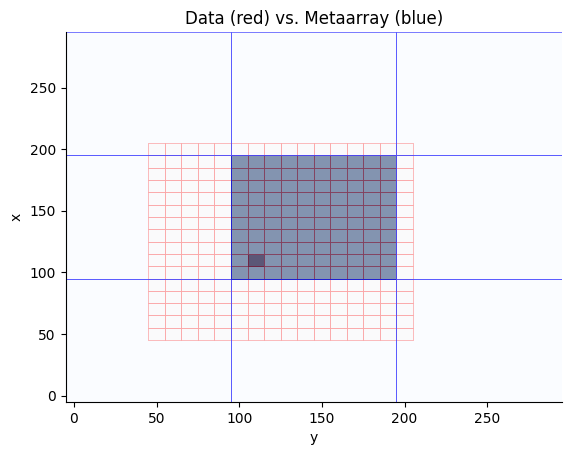

In [10]:
fig, ax = plt.subplots()
dss["foo"].plot.pcolormesh(
    linewidth=0.7, edgecolor="red", alpha=0.5, cmap="Reds", ax=ax, add_colorbar=False
)
meta["foo"].plot.pcolormesh(
    linewidth=0.7, edgecolor="blue", alpha=0.5, cmap="Blues", ax=ax, add_colorbar=False
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Data (red) vs. Metaarray (blue)")

# Mappers

Let's look a bit into what is happening in `construct_metaarray` and why we neeed the `transforms` argument.

An important abstraction is the `Mapper` class which allows translating along the 2x2 matrix of
- Pixels vs Chunks
- Indices vs Labels (physical coordinates)

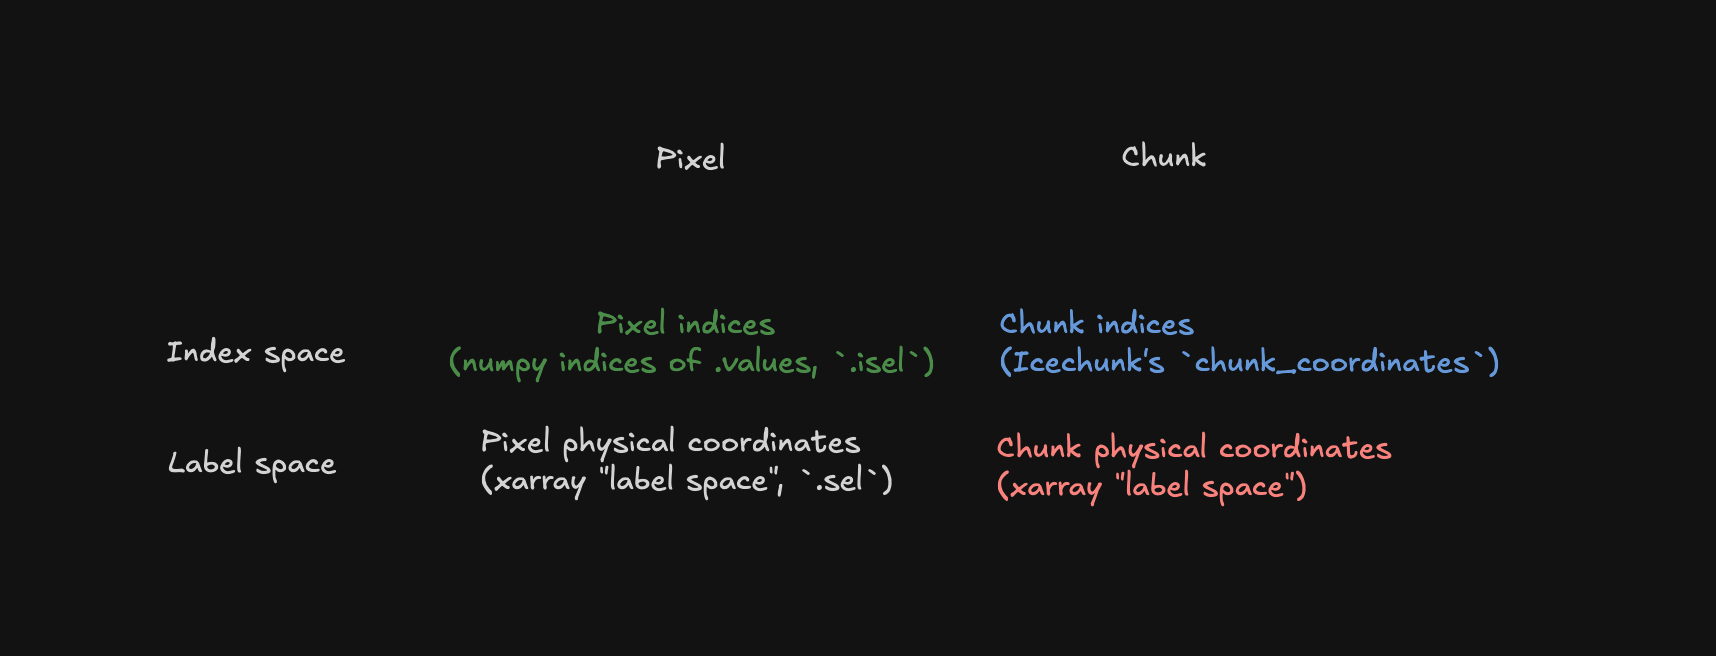

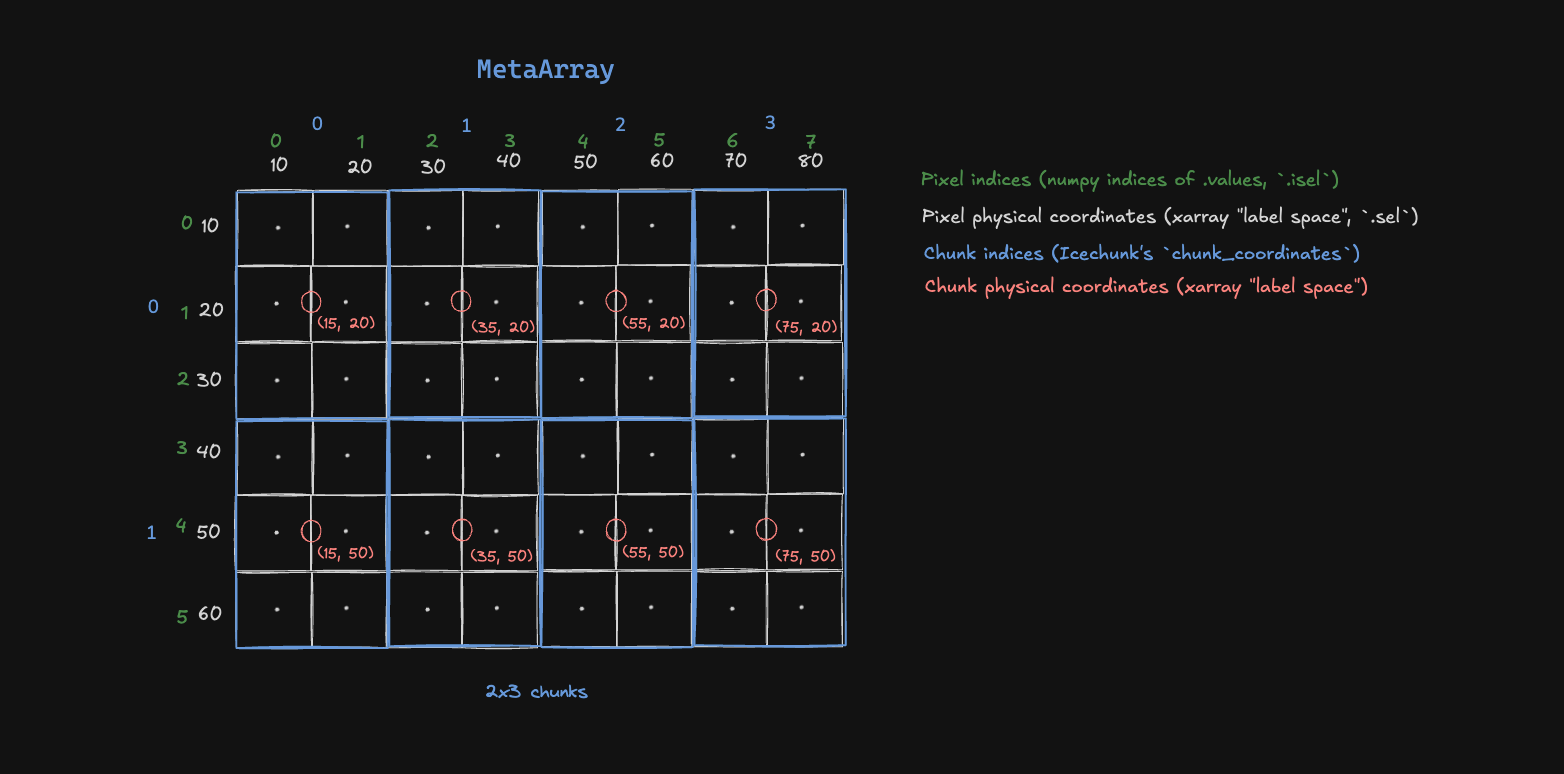

Different parts of the system work in different coordinate spaces
- The user is querying in the label space
- Icechunk returns chunk indices
- We need chunk-level array in the label space

Translating between them is done by the `Mapper` class.

In [13]:
ds

<xarray.Dataset> Size: 16TB
Dimensions:  (time: 10000, x: 10000, y: 10000)
Coordinates:
  * x        (x) int64 80kB 0 10 20 30 40 50 ... 99950 99960 99970 99980 99990
  * time     (time) datetime64[ns] 80kB 2000-01-01 2000-01-02 ... 2027-05-18
  * y        (y) int64 80kB 0 10 20 30 40 50 ... 99950 99960 99970 99980 99990
Data variables:
    bar      (time, x, y) float64 8TB ...
    foo      (time, x, y) float64 8TB ...

For example, we can see which chunk indices are there between the coordinates 100 and 200 in the label space

In [24]:
chunksizes = ds.chunk({"time": 1, "x": 10, "y": 10}).chunksizes["x"]
mapper = Mapper(coordinate=ds["x"], chunksizes=chunksizes)

In [25]:
pl2ci = MapSpec(
    from_=Spec(level=Level.PIXEL, space=Space.LABEL),
    to=Spec(level=Level.CHUNK, space=Space.INDEX),
)

In [26]:
mapper.map(specification=pl2ci, value=slice(100, 200))

array([1, 2])

However, to convert to chunk in the label space, we must provide the notion of "coordinates" to chunks.

In [28]:
pl2cl = MapSpec(
    from_=Spec(level=Level.PIXEL, space=Space.LABEL),
    to=Spec(level=Level.CHUNK, space=Space.LABEL),
)
try:
    mapper.map(specification=pl2cl, value=slice(100, 200))
except ValueError as e:
    print(e)

Cannot map to chunk label without a transform. 


This is what `transforms` does. `Centroid()` takes the endpoints of the chunk and returns the coordinates of the centroid.

In [29]:
mapper = Mapper(coordinate=ds["x"], chunksizes=chunksizes, transform=transforms["x"])
mapper.map(specification=pl2cl, value=slice(100, 200))

array([145, 245])